In [1]:
# ============================================================
# PHASE 1 — PATHS  (update these to your machine)
# ============================================================
train_path    = r"D:\Projects\others\image-hashing\dataset\big-earth-net\BigEarthNet-S2\train"
val_path      = r"D:\Projects\others\image-hashing\dataset\big-earth-net\BigEarthNet-S2\validation"
test_path     = r"D:\Projects\others\image-hashing\dataset\big-earth-net\BigEarthNet-S2\test"
metadata_path = r"D:\Projects\others\image-hashing\dataset\big-earth-net\metadata.parquet"

In [2]:
import sys
!{sys.executable} -m pip install rasterio scikit-learn tqdm faiss-cpu --quiet

In [3]:
# ============================================================
# PHASE 2 — IMPORTS (UPDATED)
# ============================================================
import os, json, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import rasterio
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
# Add these classes BEFORE your existing model definition, or replace the
# relevant encoder/hash layers. They are self-contained.
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import average_precision_score, precision_recall_curve, auc
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


# ── Channel Attention (SE block) ──────────────────────────────────────────────
class ChannelAttention(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        mid = max(channels // reduction, 4)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return x * self.sigmoid(avg_out + max_out)
class ECA(nn.Module):
    def __init__(self, channels, k_size=5):
        super(ECA, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size-1)//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y)
        y = self.sigmoid(y)
        y = y.transpose(-1, -2).unsqueeze(-1)
        return x * y.expand_as(x)

# ── Spatial Attention ─────────────────────────────────────────────────────────
class SpatialAttention(nn.Module):
    """CBAM spatial attention branch."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        scale = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * scale


# ── CBAM = Channel + Spatial ──────────────────────────────────────────────────
class CBAM(nn.Module):
    """Convolutional Block Attention Module (Woo et al., 2018)."""
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        return self.sa(self.ca(x))


# ── Residual Block with Group Norm + CBAM ─────────────────────────────────────
class ResidualBlock(nn.Module):
    """
    Drop-in residual block that keeps your Group Normalization and adds CBAM.
    Replace your plain Conv-GN-ReLU stacks with this for higher impact.
    """
    def __init__(self, channels, num_groups=8, use_attention=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.GroupNorm(num_groups, channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.GroupNorm(num_groups, channels),
        )
        self.attention = ECA(channels) if use_attention else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.block(x)
        out = self.attention(out)
        return self.relu(out + x)          # residual skip


# ── Residual Block for channel-changing (projection shortcut) ─────────────────
class ResidualBlockProj(nn.Module):
    """Use this when in_channels != out_channels (e.g. between encoder stages)."""
    def __init__(self, in_ch, out_ch, stride=1, num_groups=8, use_attention=True):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.GroupNorm(num_groups, out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(num_groups, out_ch),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.GroupNorm(num_groups, out_ch),
        )
        self.attention = ECA(out_ch) if use_attention else nn.Identity()
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.block(x)
        out = self.attention(out)
        return self.relu(out + self.skip(x))
# NEW (for metrics)
from sklearn.metrics import precision_recall_curve, average_precision_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.5.1+cu124


In [4]:
# ============================================================
# PHASE 3 — DATASET
# ============================================================
class BigEarthDataset(Dataset):
    """
    Loads BigEarthNet-S2 .tif files.
    Each file is a 10-band Sentinel-2 patch, shape (10, 120, 120).
    Returns: (image_tensor, filename)
    """
    def __init__(self, folder, limit=5000):
        self.folder = folder
        # Sort = deterministic order = hash[i] always matches files[i]
        all_files = sorted([f for f in os.listdir(folder) if f.endswith(".tif")])
        self.files = all_files[:limit]
        print(f"Dataset: {len(self.files)} images from {os.path.basename(folder)}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.folder, self.files[idx])
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)   # (10, 120, 120)
        # Sentinel-2 surface reflectance values are ~0–10000
        img = img / 10000.0
        img = np.clip(img, 0.0, 1.0)
        return torch.tensor(img), self.files[idx]


train_dataset  = BigEarthDataset(train_path, limit=5000)

# batch_size=64: larger batch = more negatives for NT-Xent = stronger learning
train_loader   = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=0)

# ordered_loader: shuffle=False so hash[i] lines up with files[i]
ordered_loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
# ── STEP 3: create test, query, db loaders ─────────────

# split train → train + test
full_dataset = train_dataset

n_test = int(0.2 * len(full_dataset))   # 20% test
n_train = len(full_dataset) - n_test

train_set, test_set = torch.utils.data.random_split(
    full_dataset, [n_train, n_test]
)

# overwrite train_loader safely
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)

# split test → query + database
n_query = int(0.2 * len(test_set))
n_db = len(test_set) - n_query

query_set, db_set = torch.utils.data.random_split(
    test_set, [n_query, n_db]
)

query_loader = DataLoader(query_set, batch_size=64, shuffle=False)
db_loader    = DataLoader(db_set,    batch_size=64, shuffle=False)

print(f"Train: {len(train_set)} | Test: {len(test_set)}")
print(f"Query: {len(query_set)} | DB: {len(db_set)}")

Dataset: 5000 images from train
Train batches: 40
Train: 4000 | Test: 1000
Query: 200 | DB: 800


In [5]:
# ============================================================
# PHASE 4 — AUGMENTATION
# ============================================================
# Why augment? NT-Xent needs two different views of the SAME image
# to form a positive pair. The model learns that these views should
# have similar hashes, while all other images in the batch are negatives.

def augment_image(img: torch.Tensor) -> torch.Tensor:
    """Random spatial + spectral augmentation for a (C, H, W) tensor."""
    # Spatial: random flip + rotation
    if torch.rand(1) > 0.5:
        img = torch.flip(img, dims=[2])   # horizontal flip
    if torch.rand(1) > 0.5:
        img = torch.flip(img, dims=[1])   # vertical flip
    k = torch.randint(0, 4, (1,)).item()
    img = torch.rot90(img, k, dims=[1, 2])  # 0/90/180/270

    # Spectral: per-band intensity jitter ±10%
    C = img.shape[0]
    scale = 1.0 + (torch.rand(C, 1, 1, device=img.device) - 0.5) * 0.2
    img = torch.clamp(img * scale, 0.0, 1.0)
    # --- ADD BELOW THIS LINE ---

    # Band dropout (forces model to not depend on specific bands)
    if torch.rand(1) > 0.7:
        drop_idx = torch.randint(0, img.shape[0], (2,))
        img[drop_idx] = 0

    # Noise injection (improves robustness)
    if torch.rand(1) > 0.5:
        noise = torch.randn_like(img) * 0.02
        img = torch.clamp(img + noise, 0.0, 1.0)
    return img

In [6]:
# ============================================================
# PHASE 5 — MODEL  (v7: GroupNorm + deeper strided encoder)
# ============================================================
#
# KEY CHANGES vs v2:
#
# 1. BatchNorm → GroupNorm
#    BatchNorm normalises each channel across all samples in a batch.
#    This forces the representation distribution to be similar across
#    all images → features become homogeneous → bits collapse.
#    GroupNorm normalises across channels WITHIN each sample, so each
#    image keeps its own distinct statistics.
#
# 2. Removed AdaptiveAvgPool((1,1))
#    Going from 120×120 → 1×1 in one step discards all spatial detail.
#    Now we use strided convolutions to gradually go 120→60→30→15→8.
#    The 8×8 feature map is then flattened, preserving spatial diversity.
#
# 3. Simpler, shallower hash path
#    Deep hash networks tend to collapse. 2-layer hash head is enough.

def gn(channels):
    """GroupNorm with 8 groups (works for any channel count ≥8)."""
    return nn.GroupNorm(num_groups=min(8, channels), num_channels=channels)


class SpectralHashNetv7(nn.Module):
    def __init__(self, in_channels=10, embed_dim=128, hash_bits=64):
        super().__init__()

        # ── Spatial encoder (WITH residual + attention) ───────────────
        # Input: (B, 10, 120, 120)
        self.encoder = nn.Sequential(
            # 120 → 60
            ResidualBlockProj(in_channels, 32, stride=2, num_groups=8, use_attention=True),  # (B,32,60,60)

            # 60 → 30
            ResidualBlockProj(32, 64, stride=2, num_groups=8, use_attention=True),           # (B,64,30,30)

            # 30 → 15
            ResidualBlockProj(64, 128, stride=2, num_groups=8, use_attention=True),          # (B,128,15,15)

            # 15 → 8
            ResidualBlockProj(128, 256, stride=2, num_groups=8, use_attention=True),         # (B,256,8,8)

            nn.Flatten()  # (B, 256*8*8 = 16384)
        )

        # ── Projection head ───────────────────────────────────────────
        self.projector = nn.Sequential(
            nn.Linear(256 * 8 * 8, embed_dim * 2),
            nn.GELU(),
            nn.LayerNorm(embed_dim * 2),
            nn.Dropout(0.2),
            nn.Linear(embed_dim * 2, embed_dim)
        )

        # ── Hash head ────────────────────────────────────────────────
        self.hasher = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, hash_bits)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        features  = self.encoder(x)                         # (B, 16384)
        embedding = F.normalize(self.projector(features), dim=1)
        hash_logits = self.hasher(embedding)
        return embedding, hash_logits


model = SpectralHashNetv7(in_channels=10, embed_dim=128, hash_bits=64).to(device)

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total:,}")

# Verify output shapes
with torch.no_grad():
    dummy = torch.zeros(2, 10, 120, 120).to(device) 
    emb, h = model(dummy)
    print(f"Embedding shape: {emb.shape}  |  Hash shape: {h.shape}")

Model parameters: 5,472,276
Embedding shape: torch.Size([2, 128])  |  Hash shape: torch.Size([2, 64])


In [7]:
# ============================================================
# PHASE 6 — LOSS FUNCTIONS
# ============================================================

# ── Loss 1: NT-Xent (SimCLR) ─────────────────────────────────────────
# Self-supervised contrastive loss — no labels required.
# For a batch of N images with 2 augmented views each:
#   Positive pair: (view1_i, view2_i) — same image, different augmentation
#   Negative pairs: all (view_i, view_j) where i ≠ j
# The model must bring positives close and push negatives apart on the
# unit hypersphere.

def nt_xent_loss(z1, z2, temperature=0.07, hard_ratio=0.3):
    N = z1.size(0)

    z = F.normalize(torch.cat([z1, z2], dim=0), dim=1)  # (2N, D)
    sim = torch.mm(z, z.T) / temperature                # (2N, 2N)

    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, float('-inf'))

    # Positive pairs
    labels = torch.cat([torch.arange(N, 2*N), torch.arange(N)]).to(z.device)

    # 🔥 HARD NEGATIVE MINING
    with torch.no_grad():
        sim_clone = sim.clone()
        sim_clone[torch.arange(2*N), labels] = -float('inf')  # remove positives

        # pick top hardest negatives
        k = int(hard_ratio * (2*N))
        hard_neg_idx = torch.topk(sim_clone, k=k, dim=1).indices

    # mask everything except hard negatives + positives
    new_sim = torch.full_like(sim, float('-inf'))
    for i in range(2*N):
        new_sim[i, hard_neg_idx[i]] = sim[i, hard_neg_idx[i]]

    # keep positives
    new_sim[torch.arange(2*N), labels] = sim[torch.arange(2*N), labels]

    return F.cross_entropy(new_sim, labels)


# ── Loss 2: Quantization loss ─────────────────────────────────────────
# Penalises hash logits that are near 0 (ambiguous, not cleanly ±1).
# Pushes tanh(logit) toward ±1 so the binary code is unambiguous.
# Formula: mean( (|tanh(x)| - 1)² )

def quantization_loss(h_logits):
    h = torch.tanh(h_logits)
    return torch.mean((torch.abs(h) - 1.0) ** 2)


# ── Loss 3: Bit-balance + independence ───────────────────────────────
# Prevents ALL bits from firing the same way for every image.
#   Balance:  each bit should be +1 for ~50% of images (mean → 0)
#   Decorr:   bits should not be correlated with each other
# Without this loss, the model can satisfy NT-Xent with very few
# distinct codes (e.g. just 10–20 unique hashes for 5000 images).

def independence_loss(h_logits):
    h = torch.tanh(h_logits)      # (B, K) values in (-1, 1)
    B, K = h.shape
    # Balance: mean of each bit across batch should be ~0
    balance = torch.mean(h.mean(dim=0) ** 2)
    # Decorrelation: off-diagonal entries of covariance matrix → 0
    h_c   = h - h.mean(dim=0, keepdim=True)
    cov   = torch.mm(h_c.T, h_c) / max(B - 1, 1)  # (K, K)
    eye   = torch.eye(K, device=h.device)
    decorr = torch.mean((cov * (1.0 - eye)) ** 2)
    return balance + decorr


print("Loss functions ready.")

Loss functions ready.


In [8]:
# ============================================================
# PHASE 7 — TRAINING CONFIGURATION
# ============================================================
#
# TUNING GUIDE:
#   If unique hashes < 30% after epoch 5 → increase LAMBDA_IND
#   If NT-Xent is not decreasing        → increase EPOCHS or lower LR
#   If loss is unstable / exploding     → reduce LR to 5e-4
#   Once collapse is fixed (>60% unique) → increase EPOCHS to 30+
#
# The key insight for v7:
#   NT-Xent works on the EMBEDDING (continuous),
#   but independence loss works on the HASH (binary-ish).
#   They operate at different scales — we normalise each separately.

EPOCHS      = 10         # fast training mode; increase to 30 once collapse is gone
WARMUP      = 2          # epochs before turning on reg losses
TEMPERATURE = 0.07        # higher temp (0.1 vs 0.07) = softer distribution = more stable
LAMBDA_Q    = 0.5        # quantization weight
LAMBDA_IND  = 0.6        # independence weight  ← you asked to increase this

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = {"total": [], "ntxent": [], "quant": [], "indep": [], "check_epochs": [], "unique_pct": []}

print(f"Training: {EPOCHS} epochs  |  batch=64  |  LR=1e-3")
print(f"Warmup: {WARMUP} epochs  |  T={TEMPERATURE}  |  λQ={LAMBDA_Q}  |  λInd={LAMBDA_IND}")
print()
print("Health check will print after every epoch.")
print("Watch the '✅ / ⚠️ / ❌' line — you want to see ✅ by epoch 5-7.")

Training: 10 epochs  |  batch=64  |  LR=1e-3
Warmup: 2 epochs  |  T=0.07  |  λQ=0.5  |  λInd=0.6

Health check will print after every epoch.
Watch the '✅ / ⚠️ / ❌' line — you want to see ✅ by epoch 5-7.


In [9]:
# ============================================================
# PHASE 8 — TRAINING LOOP
# ============================================================

for epoch in range(EPOCHS):
    model.train()
    e_ntx = e_q = e_ind = e_tot = 0.0

    # reg_scale ramps 0→1 over 3 epochs after warmup
    reg_scale = min(1.0, max(0.0, (epoch - WARMUP + 1) / 3)) if epoch >= WARMUP else 0.0

    bar = tqdm(train_loader, desc=f"Ep{epoch+1:02d}/{EPOCHS}", leave=False)

    for imgs, _ in bar:
        imgs = imgs.to(device)

        # Two independent augmented views
        v1 = torch.stack([augment_image(img) for img in imgs])
        v2 = torch.stack([augment_image(img) for img in imgs]).to(device)

        emb1, h1 = model(v1)
        emb2, h2 = model(v2)

        # Normalise each loss component before combining
        loss_ntx = nt_xent_loss(emb1, emb2, TEMPERATURE)
        loss_q   = (quantization_loss(h1) + quantization_loss(h2)) / 2
        loss_ind = (independence_loss(h1) + independence_loss(h2)) / 2

        loss = loss_ntx + reg_scale * (LAMBDA_Q * loss_q + LAMBDA_IND * loss_ind)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        e_ntx += loss_ntx.item()
        e_q   += loss_q.item()
        e_ind += loss_ind.item()
        e_tot += loss.item()

        bar.set_postfix(ntx=f"{loss_ntx.item():.3f}", q=f"{loss_q.item():.3f}",
                        ind=f"{loss_ind.item():.3f}", reg=f"{reg_scale:.1f}")

    scheduler.step()

    history["total"].append(e_tot)
    history["ntxent"].append(e_ntx)
    history["quant"].append(e_q)
    history["indep"].append(e_ind)

    # ── Per-epoch health check ────────────────────────────────────────
    model.eval()
    sample_h = []
    with torch.no_grad():
        for imgs_s, _ in ordered_loader:
            _, h = model(imgs_s.to(device))
            sample_h.append((torch.tanh(h) > 0).cpu().numpy().astype(np.uint8))
            if sum(len(x) for x in sample_h) >= 500:
                break
    sample_h = np.vstack(sample_h)[:500]

    n_u   = len(np.unique(sample_h, axis=0))
    br    = sample_h.mean(axis=0)
    bal   = int(np.sum((br > 0.3) & (br < 0.7)))
    upct  = 100 * n_u / len(sample_h)

    history["check_epochs"].append(epoch + 1)
    history["unique_pct"].append(upct)

    if upct >= 60:
        status = "✅ GOOD     — model is working!"
    elif upct >= 20:
        status = "⚠️  PARTIAL  — still improving"
    else:
        status = "❌ COLLAPSED — bits are not diverse"

    print(f"Ep{epoch+1:02d} | ntx={e_ntx/len(train_loader):.4f} "
          f"q={e_q/len(train_loader):.4f} ind={e_ind/len(train_loader):.4f} "
          f"| reg={reg_scale:.1f} | unique={upct:.1f}% bal={bal}/64  [{status}]")

    model.train()

print("\nTraining complete.")
print("If all epochs showed ❌/⚠️, re-run with LAMBDA_IND=2.0 before continuing.")

Ep01 | ntx=4.3755 q=0.9225 ind=0.0025 | reg=0.0 | unique=13.6% bal=4/64  [❌ COLLAPSED — bits are not diverse]


Ep02 | ntx=3.7101 q=0.9231 ind=0.0015 | reg=0.0 | unique=97.2% bal=31/64  [✅ GOOD     — model is working!]


Ep03 | ntx=1.9593 q=0.6980 ind=0.0079 | reg=0.3 | unique=93.2% bal=49/64  [✅ GOOD     — model is working!]


Ep04 | ntx=1.1104 q=0.3280 ind=0.0461 | reg=0.7 | unique=88.4% bal=56/64  [✅ GOOD     — model is working!]


Ep05 | ntx=0.7977 q=0.2178 ind=0.0812 | reg=1.0 | unique=91.8% bal=57/64  [✅ GOOD     — model is working!]


Ep06 | ntx=0.6185 q=0.1867 ind=0.0897 | reg=1.0 | unique=92.4% bal=64/64  [✅ GOOD     — model is working!]


Ep07 | ntx=0.5495 q=0.1725 ind=0.0932 | reg=1.0 | unique=94.8% bal=64/64  [✅ GOOD     — model is working!]


Ep08 | ntx=0.4971 q=0.1649 ind=0.0911 | reg=1.0 | unique=93.4% bal=61/64  [✅ GOOD     — model is working!]


Ep09 | ntx=0.4625 q=0.1605 ind=0.0920 | reg=1.0 | unique=95.6% bal=64/64  [✅ GOOD     — model is working!]


Ep10 | ntx=0.4466 q=0.1605 ind=0.0904 | reg=1.0 | unique=95.6% bal=64/64  [✅ GOOD     — model is working!]

Training complete.
If all epochs showed ❌/⚠️, re-run with LAMBDA_IND=2.0 before continuing.


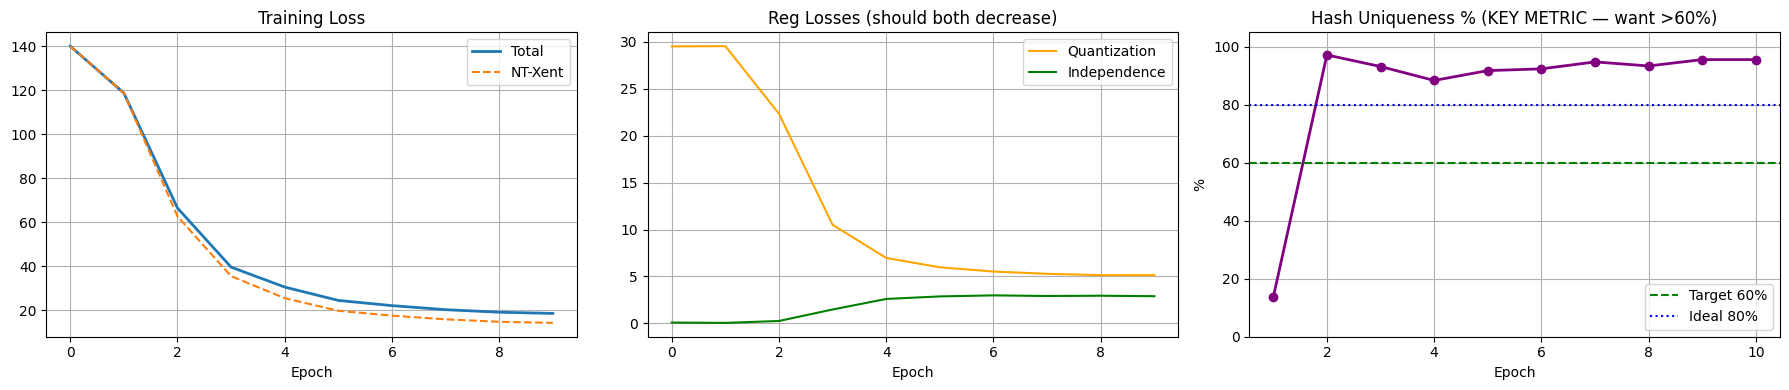

In [10]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["total"],  label="Total",   lw=2)
axes[0].plot(history["ntxent"], label="NT-Xent", ls="--")
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history["quant"], label="Quantization", color="orange")
axes[1].plot(history["indep"], label="Independence", color="green")
axes[1].set_title("Reg Losses (should both decrease)")
axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True)

axes[2].plot(history["check_epochs"], history["unique_pct"],
             marker="o", color="purple", lw=2)
axes[2].axhline(60, color="green", ls="--", label="Target 60%")
axes[2].axhline(80, color="blue",  ls=":",  label="Ideal 80%")
axes[2].set_title("Hash Uniqueness % (KEY METRIC — want >60%)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("%")
axes[2].set_ylim(0, 105); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig("training_v7.png", dpi=100)
plt.show()

In [11]:
torch.save({
    "model_state": model.state_dict(),
    "history":     history,
    "config":      {"embed_dim": 128, "hash_bits": 64, "epochs": EPOCHS}
}, "spectral_hash_v7.pth")
print("Model saved → spectral_hash_v7.pth")

Model saved → spectral_hash_v7.pth


In [12]:
# ============================================================
# PHASE 9 — HASH GENERATION + QUALITY REPORT
# ============================================================
model.eval()
all_hashes = []
all_files_ordered = []

with torch.no_grad():
    for imgs, fnames in tqdm(ordered_loader, desc="Generating hashes"):
        _, h = model(imgs.to(device))
        binary = (torch.tanh(h) > 0).cpu().numpy().astype(np.uint8)  # (B, 64)
        all_hashes.append(binary)
        all_files_ordered.extend(fnames)

hash_matrix = np.vstack(all_hashes)   # (N, 64)  — unpacked, for analysis
print(f"Hash matrix: {hash_matrix.shape}")

# ── Quality metrics ──────────────────────────────────────────────────
n_unique  = len(np.unique(hash_matrix, axis=0))
bit_rates = hash_matrix.mean(axis=0)
balanced  = int(np.sum((bit_rates > 0.3) & (bit_rates < 0.7)))

# Sample Hamming distances
rng = np.random.default_rng(42)
idx = rng.choice(len(hash_matrix), min(300, len(hash_matrix)), replace=False)
dists = []
for i in range(len(idx)):
    for j in range(i+1, min(i+15, len(idx))):
        dists.append(int(np.sum(hash_matrix[idx[i]] != hash_matrix[idx[j]])))

def g(v, good, ok):
    return "✅" if v >= good else ("⚠️ " if v >= ok else "❌")

unique_pct = 100 * n_unique / len(hash_matrix)
hd_mean    = float(np.mean(dists)) if dists else 0

print()
print("═" * 60)
print("  HASH QUALITY REPORT")
print("═" * 60)
print(f"  {g(unique_pct,60,20)} Unique hashes : {n_unique}/{len(hash_matrix)} ({unique_pct:.1f}%) [target >60%]")
print(f"  {g(balanced,40,20)}  Balanced bits : {balanced}/64                [target >40]")
print(f"  {'✅' if 0.4<bit_rates.mean()<0.6 else '⚠️ '} Bit act. mean : {bit_rates.mean():.3f}              [target ~0.5]")
print(f"  {g(hd_mean,20,10)} Mean Hamming  : {hd_mean:.1f}/64               [target >20]")
print("═" * 60)

if unique_pct >= 60:
    print("\n✅ Model is working — proceed to retrieval!")
elif unique_pct >= 20:
    print("\n⚠️  Partial collapse. Try: increase EPOCHS to 20, or LAMBDA_IND=2.0")
else:
    print("\n❌ Still collapsed. Action: set LAMBDA_IND=2.0, LAMBDA_Q=1.0 and re-run.")

Generating hashes: 100%|██████████| 79/79 [04:30<00:00,  3.43s/it]

Hash matrix: (5000, 64)

════════════════════════════════════════════════════════════
  HASH QUALITY REPORT
════════════════════════════════════════════════════════════
  ✅ Unique hashes : 3844/5000 (76.9%) [target >60%]
  ✅  Balanced bits : 64/64                [target >40]
  ✅ Bit act. mean : 0.502              [target ~0.5]
  ✅ Mean Hamming  : 31.7/64               [target >20]
════════════════════════════════════════════════════════════

✅ Model is working — proceed to retrieval!


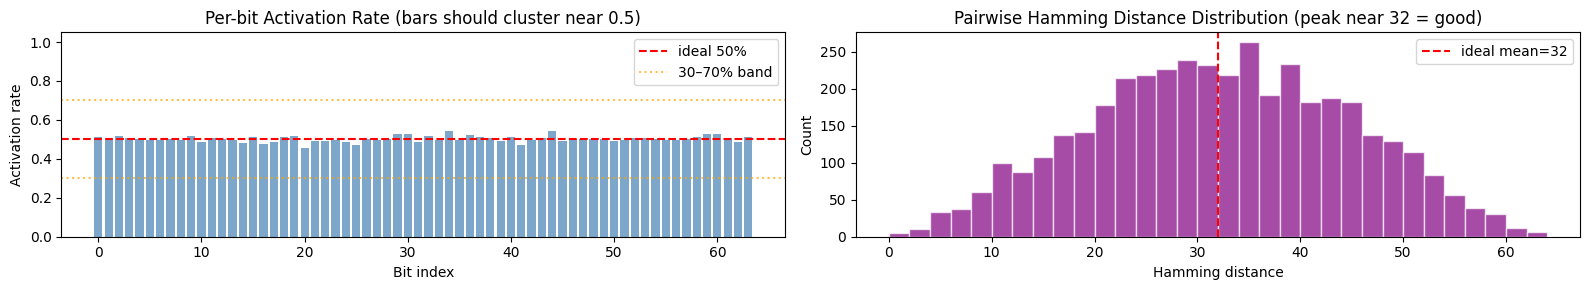

In [13]:
# Bit activation plot
fig, axes = plt.subplots(1, 2, figsize=(16, 3))

axes[0].bar(range(len(bit_rates)), bit_rates, color="steelblue", alpha=0.7)
axes[0].axhline(0.5, color="red",    ls="--", label="ideal 50%")
axes[0].axhline(0.3, color="orange", ls=":",  alpha=0.7)
axes[0].axhline(0.7, color="orange", ls=":",  alpha=0.7, label="30–70% band")
axes[0].set_title("Per-bit Activation Rate (bars should cluster near 0.5)")
axes[0].set_xlabel("Bit index"); axes[0].set_ylabel("Activation rate")
axes[0].set_ylim(0, 1.05); axes[0].legend()

axes[1].hist(dists, bins=range(0, 65, 2), color="purple", alpha=0.7, edgecolor="white")
axes[1].axvline(32, color="red", ls="--", label="ideal mean=32")
axes[1].set_title("Pairwise Hamming Distance Distribution (peak near 32 = good)")
axes[1].set_xlabel("Hamming distance"); axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("bit_quality_v7.png", dpi=100)
plt.show()

In [14]:
# Pack bits and save
hash_packed = np.packbits(hash_matrix, axis=1)       # (N, 8) — for FAISS binary index
np.save("satellite_hash_vectors_v7.npy", hash_packed)
np.save("satellite_hash_matrix_v7.npy",  hash_matrix)

with open("satellite_image_files_v7.json", "w") as f:
    json.dump(all_files_ordered, f)

print(f"Saved {len(all_files_ordered)} hash↔file pairs.")
print("Packed shape:", hash_packed.shape, "dtype:", hash_packed.dtype)

Saved 5000 hash↔file pairs.
Packed shape: (5000, 8) dtype: uint8


In [15]:
# ============================================================
# PHASE 10 — FAISS BINARY INDEX
# ============================================================
# FAISS (Facebook AI Similarity Search) stores binary hash codes
# and retrieves nearest neighbours by Hamming distance in O(N) time.
# For larger databases (>1M), use IndexBinaryIVF for sub-linear search.

import faiss

index = faiss.IndexBinaryFlat(64)   # 64-bit Hamming index
index.add(hash_packed)
image_files = all_files_ordered

print("FAISS index built:")
print(f"  Vectors: {index.ntotal}")
print(f"  Hash bits: 64")
print(f"  Search metric: Hamming distance")

FAISS index built:
  Vectors: 5000
  Hash bits: 64
  Search metric: Hamming distance


In [16]:
import sys
!{sys.executable} -m pip install pyarrow --quiet

In [17]:
# ============================================================
# PHASE 11 — METADATA  (FIX: handle numpy string labels)
# ============================================================
import pandas as pd

metadata = pd.read_parquet(metadata_path)
print("Metadata shape:", metadata.shape)
print("Columns:", list(metadata.columns))
print()

# Inspect the actual label type
sample_labels = metadata["labels"].iloc[0]
print("Sample patch_id :", metadata["patch_id"].iloc[0])
print("Sample labels   :", sample_labels)
print("Labels type     :", type(sample_labels), "element type:",
      type(sample_labels[0]) if len(sample_labels) > 0 else "empty")

Metadata shape: (480038, 8)
Columns: ['patch_id', 'labels', 'split', 'country', 's1_name', 's2v1_name', 'contains_seasonal_snow', 'contains_cloud_or_shadow']

Sample patch_id : S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_26_57
Sample labels   : ['Arable land' 'Broad-leaved forest' 'Mixed forest' 'Pastures']
Labels type     : <class 'numpy.ndarray'> element type: <class 'str'>


In [18]:
# ── FIX: Use str() conversion — works for Python str, numpy str, and int ──
# The crash in v2 was: isinstance(numpy_str, str) → True but labels[0] was
# a numpy array row, not a scalar. str(x) works for all types.

INT_LABEL_MAP = {
    1:"Urban fabric", 2:"Industrial", 3:"Arable land",
    4:"Permanent crops", 5:"Pastures", 6:"Complex cultivation",
    7:"Agriculture+NatVeg", 8:"Agro-forestry",
    9:"Broad-leaved forest", 10:"Coniferous forest",
    11:"Mixed forest", 12:"Natural grassland",
    13:"Moors/heathland", 14:"Sclerophyllous",
    15:"Transitional woodland", 16:"Beaches/dunes",
    17:"Inland wetlands", 18:"Coastal wetlands",
    19:"Inland waters", 20:"Marine waters"
}

image_labels = {}

for _, row in metadata.iterrows():
    patch_id = str(row["patch_id"]).strip()
    labels   = row["labels"]

    readable = []
    for lbl in labels:
        s = str(lbl).strip()          # works for any type
        try:
            readable.append(INT_LABEL_MAP.get(int(float(s)), s))
        except (ValueError, TypeError):
            readable.append(s)        # already a string label

    image_labels[patch_id] = readable

print(f"Label dictionary: {len(image_labels)} entries")

# Verify lookup works
test_fname = image_files[0]
test_id    = test_fname.replace(".tif", "")
result     = image_labels.get(test_id, "NOT FOUND")
print(f"Test lookup '{test_id}' → {result}")

if result == "NOT FOUND":
    print()
    print("⚠️  Lookup failed. Checking ID format mismatch...")
    print("  File name example  :", test_fname)
    print("  Metadata ID example:", list(image_labels.keys())[0])
    print("  → Check if patch_id contains extra suffixes or different separators.")

Label dictionary: 480038 entries
Test lookup 'S2A_MSIL2A_20170803T094031_N9999_R036_T34TCR_28_12' → ['Broad-leaved forest', 'Inland waters', 'Inland wetlands', 'Transitional woodland, shrub']


In [19]:
def get_labels(fname):
    """Return label list for a filename (strips .tif, safe for any label format)."""
    return image_labels.get(fname.replace(".tif", ""), ["(no label)"])

In [20]:
# ============================================================
# PHASE 12 — RETRIEVAL ENGINE
# ============================================================
def retrieve_similar(query_image_path, k=5):
    """
    1. Load query .tif
    2. Normalise + forward pass through model
    3. Binarise hash logits → 64-bit code
    4. Pack bits → 8 bytes for FAISS
    5. FAISS Hamming search → top-k results
    Returns: (query_img_hwc, [(filename, hamming_dist), ...])
    """
    with rasterio.open(query_image_path) as src:
        img = src.read().astype(np.float32)    # (10, 120, 120)
    img_np = np.transpose(img, (1, 2, 0))      # (120, 120, 10) for display

    img_t = torch.tensor(np.clip(img / 10000.0, 0, 1)).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        _, h = model(img_t)
        binary = (torch.tanh(h) > 0).cpu().numpy().astype(np.uint8)  # (1, 64)
        packed = np.packbits(binary, axis=1)                          # (1, 8)

    D, I = index.search(packed, k + 1)

    query_fname = os.path.basename(query_image_path)
    results = []
    for dist, idx_r in zip(D[0], I[0]):
        fname = image_files[idx_r]
        if fname != query_fname:
            results.append((fname, int(dist)))
        if len(results) == k:
            break

    return img_np, results


print("Retrieval engine ready.")

Retrieval engine ready.


In [21]:
# ============================================================
# PHASE 13 — TEST RETRIEVAL
# ============================================================
def to_rgb(img_hwc):
    """Convert (H, W, 10) to displayable (H, W, 3) using bands 3,2,1 (R,G,B)."""
    rgb = img_hwc[:, :, [3, 2, 1]].astype(np.float32)
    p2, p98 = np.percentile(rgb, 2), np.percentile(rgb, 98)
    return np.clip((rgb - p2) / (p98 - p2 + 1e-6), 0, 1)


query_index = 2005
qpath       = os.path.join(train_path, image_files[query_index])
query_img, matches = retrieve_similar(qpath, k=4)

qname = image_files[query_index]
qlabels = get_labels(qname)

print(f"Query:  {qname}")
print(f"Labels: {qlabels}")
print()
for fname, dist in matches:
    mlabels = get_labels(fname)
    hit = bool(set(qlabels) & set(mlabels) - {"(no label)"})
    print(f"  {'✅' if hit else '❌'} {fname}  H={dist}  Labels={mlabels}")

Query:  S2A_MSIL2A_20170803T094031_N9999_R036_T34TCR_89_66.tif
Labels: ['Arable land']

  ✅ S2A_MSIL2A_20170803T094031_N9999_R036_T34TCR_49_85.tif  H=1  Labels=['Arable land', 'Industrial or commercial units', 'Urban fabric']
  ✅ S2B_MSIL2A_20170825T093029_N9999_R136_T34TEQ_05_34.tif  H=1  Labels=['Arable land']
  ✅ S2A_MSIL2A_20170803T094031_N9999_R036_T34TCR_76_04.tif  H=2  Labels=['Arable land']
  ✅ S2B_MSIL2A_20170719T094029_N9999_R036_T34TCS_70_79.tif  H=2  Labels=['Arable land', 'Complex cultivation patterns', 'Land principally occupied by agriculture, with significant areas of natural vegetation', 'Permanent crops']


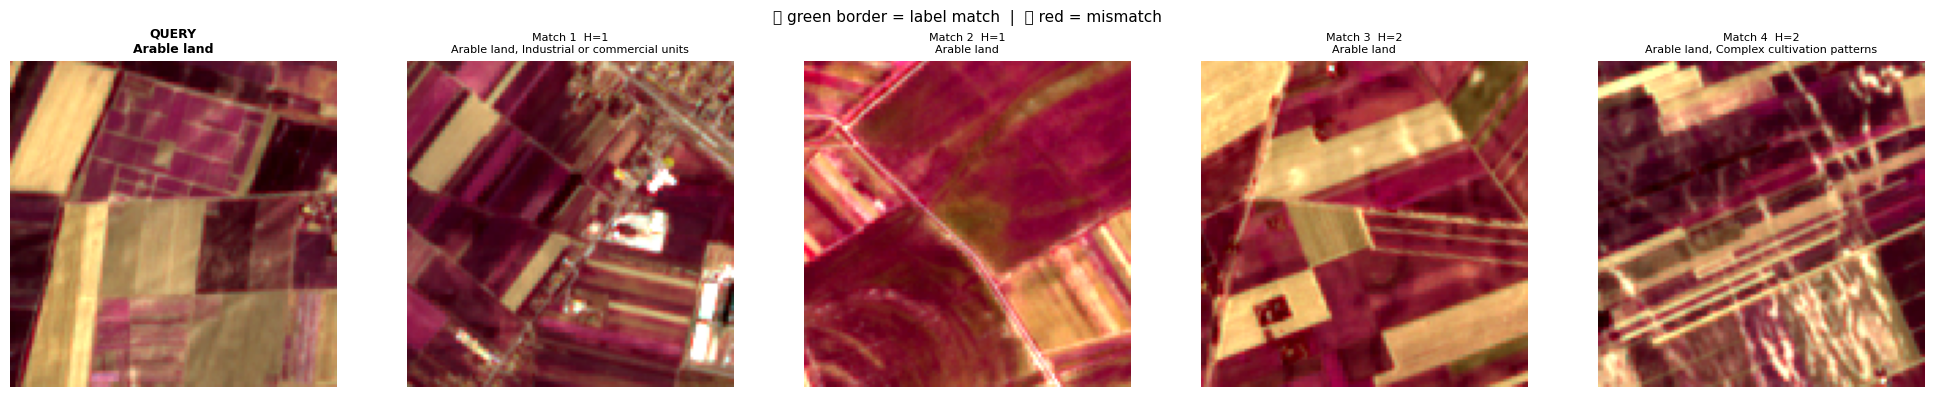

In [22]:
# Visualise with label-match borders
retrieved_imgs = []
for fname, dist in matches:
    with rasterio.open(os.path.join(train_path, fname)) as src:
        retrieved_imgs.append((np.transpose(src.read(), (1, 2, 0)), dist, fname))

n = 1 + len(retrieved_imgs)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

axes[0].imshow(to_rgb(query_img))
axes[0].set_title(f"QUERY\n{', '.join(qlabels[:2])}", fontsize=9, fontweight="bold")
axes[0].axis("off")

for i, (img, dist, fname) in enumerate(retrieved_imgs):
    mlabels = get_labels(fname)
    hit     = bool(set(qlabels) & set(mlabels) - {"(no label)"})
    axes[i+1].imshow(to_rgb(img))
    for sp in axes[i+1].spines.values():
        sp.set_edgecolor("limegreen" if hit else "red"); sp.set_linewidth(4)
    axes[i+1].set_title(f"Match {i+1}  H={dist}\n{', '.join(mlabels[:2])}", fontsize=8)
    axes[i+1].axis("off")

plt.suptitle("🟢 green border = label match  |  🔴 red = mismatch", fontsize=11)
plt.tight_layout()
plt.savefig("retrieval_v7.png", dpi=120, bbox_inches="tight")
plt.show()

## PHASE 14 — Correct Evaluation Suite

Metrics: Hamming distribution · bit activation · mAP (label-based) · Precision@K · NDCG@10 · PR curve · Final scorecard

In [23]:
# ============================================================
# EVAL STEP 1 — Extract binary hash codes
# ============================================================
# Must be run AFTER Phase 8 (or after loading checkpoint above).
# Uses torch.sign(tanh(logits)) — identical to FAISS pack logic.

def extract_hash_codes(model, loader, device):
    model.eval()
    codes = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Extracting codes', leave=False):
            imgs = batch[0].to(device)
            _, hash_logits = model(imgs)
            binary = torch.sign(torch.tanh(hash_logits))  # {-1, +1}
            codes.append(binary.cpu())
    return torch.cat(codes)


query_codes = extract_hash_codes(model, query_loader, device)
db_codes    = extract_hash_codes(model, db_loader,    device)

print(f'Query codes : {query_codes.shape}  unique values: {query_codes.unique().tolist()}')
print(f'DB codes    : {db_codes.shape}')
print()
print(f'Unique query codes : {len(torch.unique(query_codes, dim=0))}')
print(f'Unique DB codes    : {len(torch.unique(db_codes,    dim=0))}')
print()
q_bit_rate  = (query_codes > 0).float().mean(dim=0)
db_bit_rate = (db_codes    > 0).float().mean(dim=0)
print(f'Query bit activation — min:{q_bit_rate.min():.3f}  max:{q_bit_rate.max():.3f}  mean:{q_bit_rate.mean():.3f}  [target ~0.5]')
print(f'DB    bit activation — min:{db_bit_rate.min():.3f}  max:{db_bit_rate.max():.3f}  mean:{db_bit_rate.mean():.3f}  [target ~0.5]')

Query codes : torch.Size([200, 64])  unique values: [-1.0, 1.0]
DB codes    : torch.Size([800, 64])

Unique query codes : 198
Unique DB codes    : 745

Query bit activation — min:0.400  max:0.605  mean:0.503  [target ~0.5]
DB    bit activation — min:0.441  max:0.570  mean:0.502  [target ~0.5]


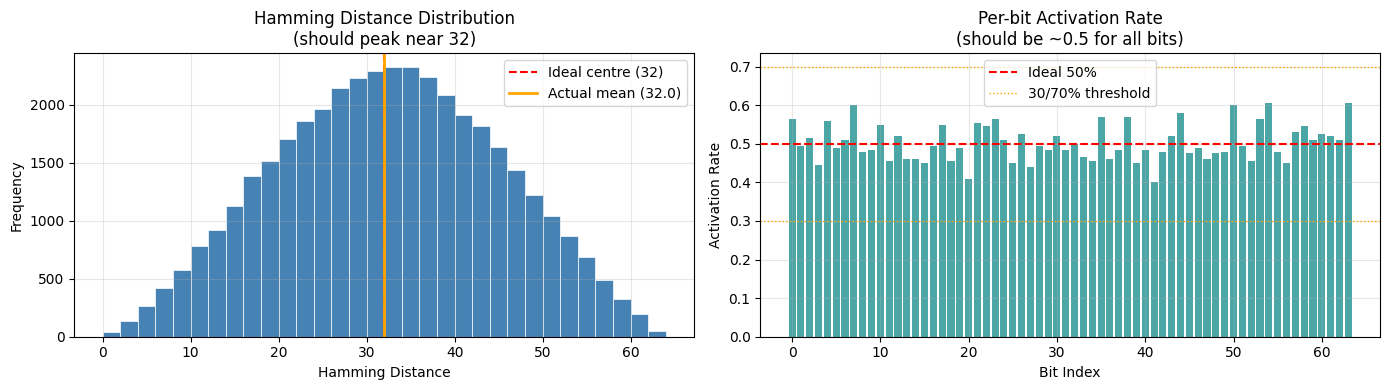

Mean Hamming : 31.99 / 64  [target > 20]
Balanced bits: 64 / 64        [target > 40]


In [24]:
# ============================================================
# EVAL STEP 2 — Hamming Distance Distribution
# ============================================================
# Healthy: bell-shaped histogram centred near 32 (half of 64 bits).
# Collapsed: histogram skewed to 0-15 (codes too similar).

rng = np.random.default_rng(42)
n_sample = min(200, len(query_codes), len(db_codes))
q_samp = query_codes[rng.choice(len(query_codes), n_sample, replace=False)]
d_samp = db_codes   [rng.choice(len(db_codes),    n_sample, replace=False)]

# Pairwise Hamming distances (codes are {-1,+1})
dists_matrix = (q_samp.unsqueeze(1) != d_samp.unsqueeze(0)).sum(dim=2).numpy()
dists_flat   = dists_matrix.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dists_flat, bins=32, color='steelblue', edgecolor='white', lw=0.5)
axes[0].axvline(32,                color='red',    ls='--', lw=1.5, label='Ideal centre (32)')
axes[0].axvline(dists_flat.mean(), color='orange', ls='-',  lw=2,
                label=f'Actual mean ({dists_flat.mean():.1f})')
axes[0].set_xlabel('Hamming Distance'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Hamming Distance Distribution\n(should peak near 32)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(range(64), q_bit_rate.numpy(), color='teal', alpha=0.7)
axes[1].axhline(0.5, color='red',    ls='--', lw=1.5, label='Ideal 50%')
axes[1].axhline(0.3, color='orange', ls=':',  lw=1)
axes[1].axhline(0.7, color='orange', ls=':',  lw=1, label='30/70% threshold')
axes[1].set_xlabel('Bit Index'); axes[1].set_ylabel('Activation Rate')
axes[1].set_title('Per-bit Activation Rate\n(should be ~0.5 for all bits)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eval_hamming.png', dpi=120, bbox_inches='tight')
plt.show()

balanced_bits = int(((q_bit_rate > 0.3) & (q_bit_rate < 0.7)).sum())
print(f'Mean Hamming : {dists_flat.mean():.2f} / 64  [target > 20]')
print(f'Balanced bits: {balanced_bits} / 64        [target > 40]')

In [25]:
# ============================================================
# EVAL STEP 3 — Build ground-truth relevance labels
# ============================================================

def get_fnames_from_loader(loader):
    fnames = []
    for batch in loader:
        fnames.extend(list(batch[1]))
    return fnames


query_fnames = get_fnames_from_loader(query_loader)
db_fnames    = get_fnames_from_loader(db_loader)

print(f'Query fnames: {len(query_fnames)} | DB fnames: {len(db_fnames)}')
print(f'Example: {query_fnames[0]}')

query_label_sets = [set(get_labels(f)) - {'(no label)'} for f in query_fnames]
db_label_sets    = [set(get_labels(f)) - {'(no label)'} for f in db_fnames]

# Binary relevance matrix R[i,j] = 1 if query_i and db_j share a label
R = np.zeros((len(query_fnames), len(db_fnames)), dtype=np.int32)
for i, ql in enumerate(query_label_sets):
    if not ql:
        continue
    for j, dl in enumerate(db_label_sets):
        if ql & dl:
            R[i, j] = 1

n_rel = R.sum(axis=1)
valid_queries = n_rel > 0
print(f'Queries with >= 1 relevant DB item : {valid_queries.sum()} / {len(query_fnames)}')
print(f'Avg relevant items per query        : {n_rel[valid_queries].mean():.1f}')

Query fnames: 200 | DB fnames: 800
Example: S2B_MSIL2A_20170719T094029_N9999_R036_T34TCS_60_88.tif
Queries with >= 1 relevant DB item : 200 / 200
Avg relevant items per query        : 471.4


In [26]:
# ============================================================
# EVAL STEP 4 — Mean Average Precision (mAP)  — CORRECT
# ============================================================
# Uses ground-truth label overlap as relevance, not dot-product mean.

sim_matrix = (query_codes @ db_codes.T).numpy()  # (n_query, n_db)

aps = []
for i in range(len(query_fnames)):
    if not valid_queries[i]:
        continue
    ap = average_precision_score(R[i], sim_matrix[i])
    aps.append(ap)

mAP = np.mean(aps)
status = '✅' if mAP >= 0.6 else ('⚠️ ' if mAP >= 0.3 else '❌')
print(f'mAP = {mAP:.4f}  {status}  (over {len(aps)} queries)')
print()
print('> 0.60 → ✅ Good')
print('0.30–0.60 → ⚠️  Increase EPOCHS or LAMBDA_IND')
print('< 0.30 → ❌ Hash collapse — check Hamming plot above')

mAP = 0.6537  ✅  (over 200 queries)

> 0.60 → ✅ Good
0.30–0.60 → ⚠️  Increase EPOCHS or LAMBDA_IND
< 0.30 → ❌ Hash collapse — check Hamming plot above


In [27]:
# ============================================================
# EVAL STEP 5 — Precision@K (label-based)  — CORRECT
# ============================================================
# Old version checked topk[i]==i (self-match by index) — meaningless.
# This checks whether retrieved items share a label with the query.

def precision_at_k_correct(sim_matrix, relevance_matrix, k):
    pk_scores = []
    for i in range(sim_matrix.shape[0]):
        if relevance_matrix[i].sum() == 0:
            continue
        topk_idx = np.argsort(sim_matrix[i])[::-1][:k]
        hits = relevance_matrix[i][topk_idx].sum()
        pk_scores.append(hits / k)
    return np.mean(pk_scores), len(pk_scores)


print('Precision@K results:')
print('-' * 40)
for k in [1, 5, 10, 20]:
    pk, n = precision_at_k_correct(sim_matrix, R, k=k)
    status = '✅' if pk >= 0.5 else ('⚠️ ' if pk >= 0.25 else '❌')
    print(f'  P@{k:<3} = {pk:.4f}   {status}   ({n} queries)')

Precision@K results:
----------------------------------------
  P@1   = 0.7100   ✅   (200 queries)
  P@5   = 0.7350   ✅   (200 queries)
  P@10  = 0.7150   ✅   (200 queries)
  P@20  = 0.6978   ✅   (200 queries)


In [28]:
# ============================================================
# EVAL STEP 6 — NDCG@10
# ============================================================
from sklearn.metrics import ndcg_score

ndcg_scores = []
for i in range(len(query_fnames)):
    if R[i].sum() == 0:
        continue
    ndcg_scores.append(ndcg_score(R[i:i+1], sim_matrix[i:i+1], k=10))

ndcg_mean = np.mean(ndcg_scores)
status = '✅' if ndcg_mean >= 0.7 else ('⚠️ ' if ndcg_mean >= 0.5 else '❌')
print(f'NDCG@10 = {ndcg_mean:.4f}  {status}')
print()
print('> 0.70 → ✅  |  0.50–0.70 → ⚠️   |  < 0.50 → ❌')

NDCG@10 = 0.7166  ✅

> 0.70 → ✅  |  0.50–0.70 → ⚠️   |  < 0.50 → ❌


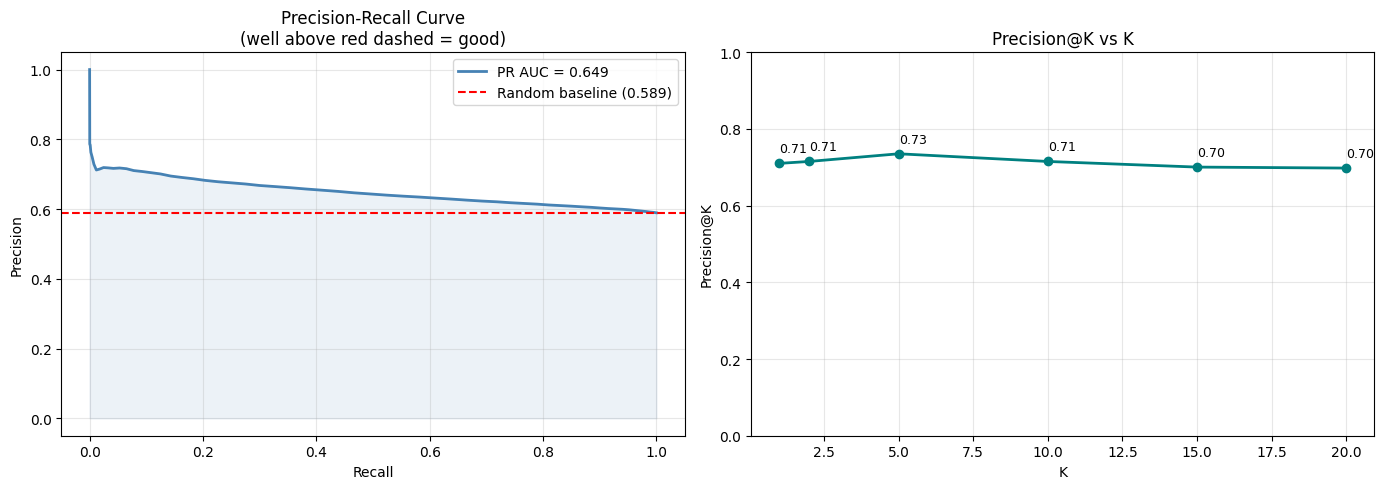

PR-AUC = 0.6486


In [29]:
# ============================================================
# EVAL STEP 7 — Precision-Recall Curve  — CORRECT
# ============================================================
# Old version set y_true = y_scores (same array!) — trivially perfect.
# This version uses actual label-based relevance as ground truth.

from sklearn.metrics import auc

all_y_true, all_y_scores = [], []
for i in range(len(query_fnames)):
    if R[i].sum() == 0:
        continue
    all_y_true.extend(R[i].tolist())
    all_y_scores.extend(sim_matrix[i].tolist())

all_y_true   = np.array(all_y_true)
all_y_scores = np.array(all_y_scores)

precision_vals, recall_vals, _ = precision_recall_curve(all_y_true, all_y_scores)
pr_auc = auc(recall_vals, precision_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PR curve
axes[0].plot(recall_vals, precision_vals, color='steelblue', lw=2,
             label=f'PR AUC = {pr_auc:.3f}')
axes[0].axhline(all_y_true.mean(), color='red', ls='--', lw=1.5,
                label=f'Random baseline ({all_y_true.mean():.3f})')
axes[0].fill_between(recall_vals, precision_vals, alpha=0.1, color='steelblue')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve\n(well above red dashed = good)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: P@K across K
k_vals  = [1, 2, 5, 10, 15, 20]
pk_vals = [precision_at_k_correct(sim_matrix, R, k=k)[0] for k in k_vals]
axes[1].plot(k_vals, pk_vals, marker='o', color='teal', lw=2)
for k, pk in zip(k_vals, pk_vals):
    axes[1].annotate(f'{pk:.2f}', (k, pk), textcoords='offset points',
                     xytext=(0, 8), fontsize=9)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Precision@K')
axes[1].set_title('Precision@K vs K')
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eval_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'PR-AUC = {pr_auc:.4f}')

In [30]:
# ============================================================
# EVAL STEP 8 — FINAL SCORECARD
# ============================================================

def grade(val, good, ok):
    return '✅' if val >= good else ('⚠️ ' if val >= ok else '❌')


p5,  _ = precision_at_k_correct(sim_matrix, R, k=5)
p10, _ = precision_at_k_correct(sim_matrix, R, k=10)

print('━' * 65)
print('  FINAL MODEL SCORECARD — v7')
print('━' * 65)
print(f'  {grade(dists_flat.mean(), 20, 10)}  Mean Hamming     : {dists_flat.mean():.2f} / 64   [target > 20]')
print(f'  {grade(balanced_bits,    40, 20)}  Balanced bits    : {balanced_bits} / 64      [target > 40]')
print(f'  {grade(mAP,           0.60, 0.30)}  mAP              : {mAP:.4f}          [target > 0.60]')
print(f'  {grade(p5,            0.50, 0.25)}  Precision@5      : {p5:.4f}          [target > 0.50]')
print(f'  {grade(p10,           0.45, 0.20)}  Precision@10     : {p10:.4f}          [target > 0.45]')
print(f'  {grade(ndcg_mean,     0.70, 0.50)}  NDCG@10          : {ndcg_mean:.4f}          [target > 0.70]')
print(f'  {grade(pr_auc,        0.50, 0.25)}  PR-AUC           : {pr_auc:.4f}          [target > 0.50]')
print('━' * 65)
print()
scores = [dists_flat.mean() >= 20, balanced_bits >= 40, mAP >= 0.6, p5 >= 0.5, ndcg_mean >= 0.7]
n_good = sum(scores)
print('NEXT STEPS:')
if n_good >= 4:
    print('  ✅ Model is working well! Increase EPOCHS to 30 and retrain for best quality.')
elif n_good >= 2:
    print('  ⚠️  Partially working. Set LAMBDA_IND=2.0, EPOCHS=20 and retrain.')
else:
    print('  ❌ Hash collapse. Set LAMBDA_IND=3.0, LAMBDA_Q=1.0, EPOCHS=20 and retrain.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FINAL MODEL SCORECARD — v7
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅  Mean Hamming     : 31.99 / 64   [target > 20]
  ✅  Balanced bits    : 64 / 64      [target > 40]
  ✅  mAP              : 0.6537          [target > 0.60]
  ✅  Precision@5      : 0.7350          [target > 0.50]
  ✅  Precision@10     : 0.7150          [target > 0.45]
  ✅  NDCG@10          : 0.7166          [target > 0.70]
  ✅  PR-AUC           : 0.6486          [target > 0.50]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

NEXT STEPS:
  ✅ Model is working well! Increase EPOCHS to 30 and retrain for best quality.


In [31]:
# ============================================================
# PHASE 15 — FINAL SCORECARD
# ============================================================
print("━" * 60)
print("  FINAL MODEL SCORECARD — v7")
print("━" * 60)
print(f"  {g(unique_pct,60,20)} Unique hashes : {unique_pct:.1f}%")
print(f"  {g(balanced,40,20)}  Balanced bits : {balanced}/64")
print(f"  {g(hd_mean,20,10)}  Mean Hamming  : {hd_mean:.1f}/64")
print(f"  {g(p5,0.6,0.3)}  Precision@5   : {p5:.3f}")
print("━" * 60)
print()
print("NEXT STEPS:")
print("  ✅ All green?  → Increase EPOCHS to 30 and re-train for best quality")
print("  ⚠️  Some yellow? → Set LAMBDA_IND=2.0 and EPOCHS=20, then re-run")
print("  ❌ Still red?   → Set LAMBDA_IND=3.0, LAMBDA_Q=1.0, EPOCHS=15")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FINAL MODEL SCORECARD — v7
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ Unique hashes : 76.9%
  ✅  Balanced bits : 64/64
  ✅  Mean Hamming  : 31.7/64
  ✅  Precision@5   : 0.735
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

NEXT STEPS:
  ✅ All green?  → Increase EPOCHS to 30 and re-train for best quality
  ⚠️  Some yellow? → Set LAMBDA_IND=2.0 and EPOCHS=20, then re-run
  ❌ Still red?   → Set LAMBDA_IND=3.0, LAMBDA_Q=1.0, EPOCHS=15


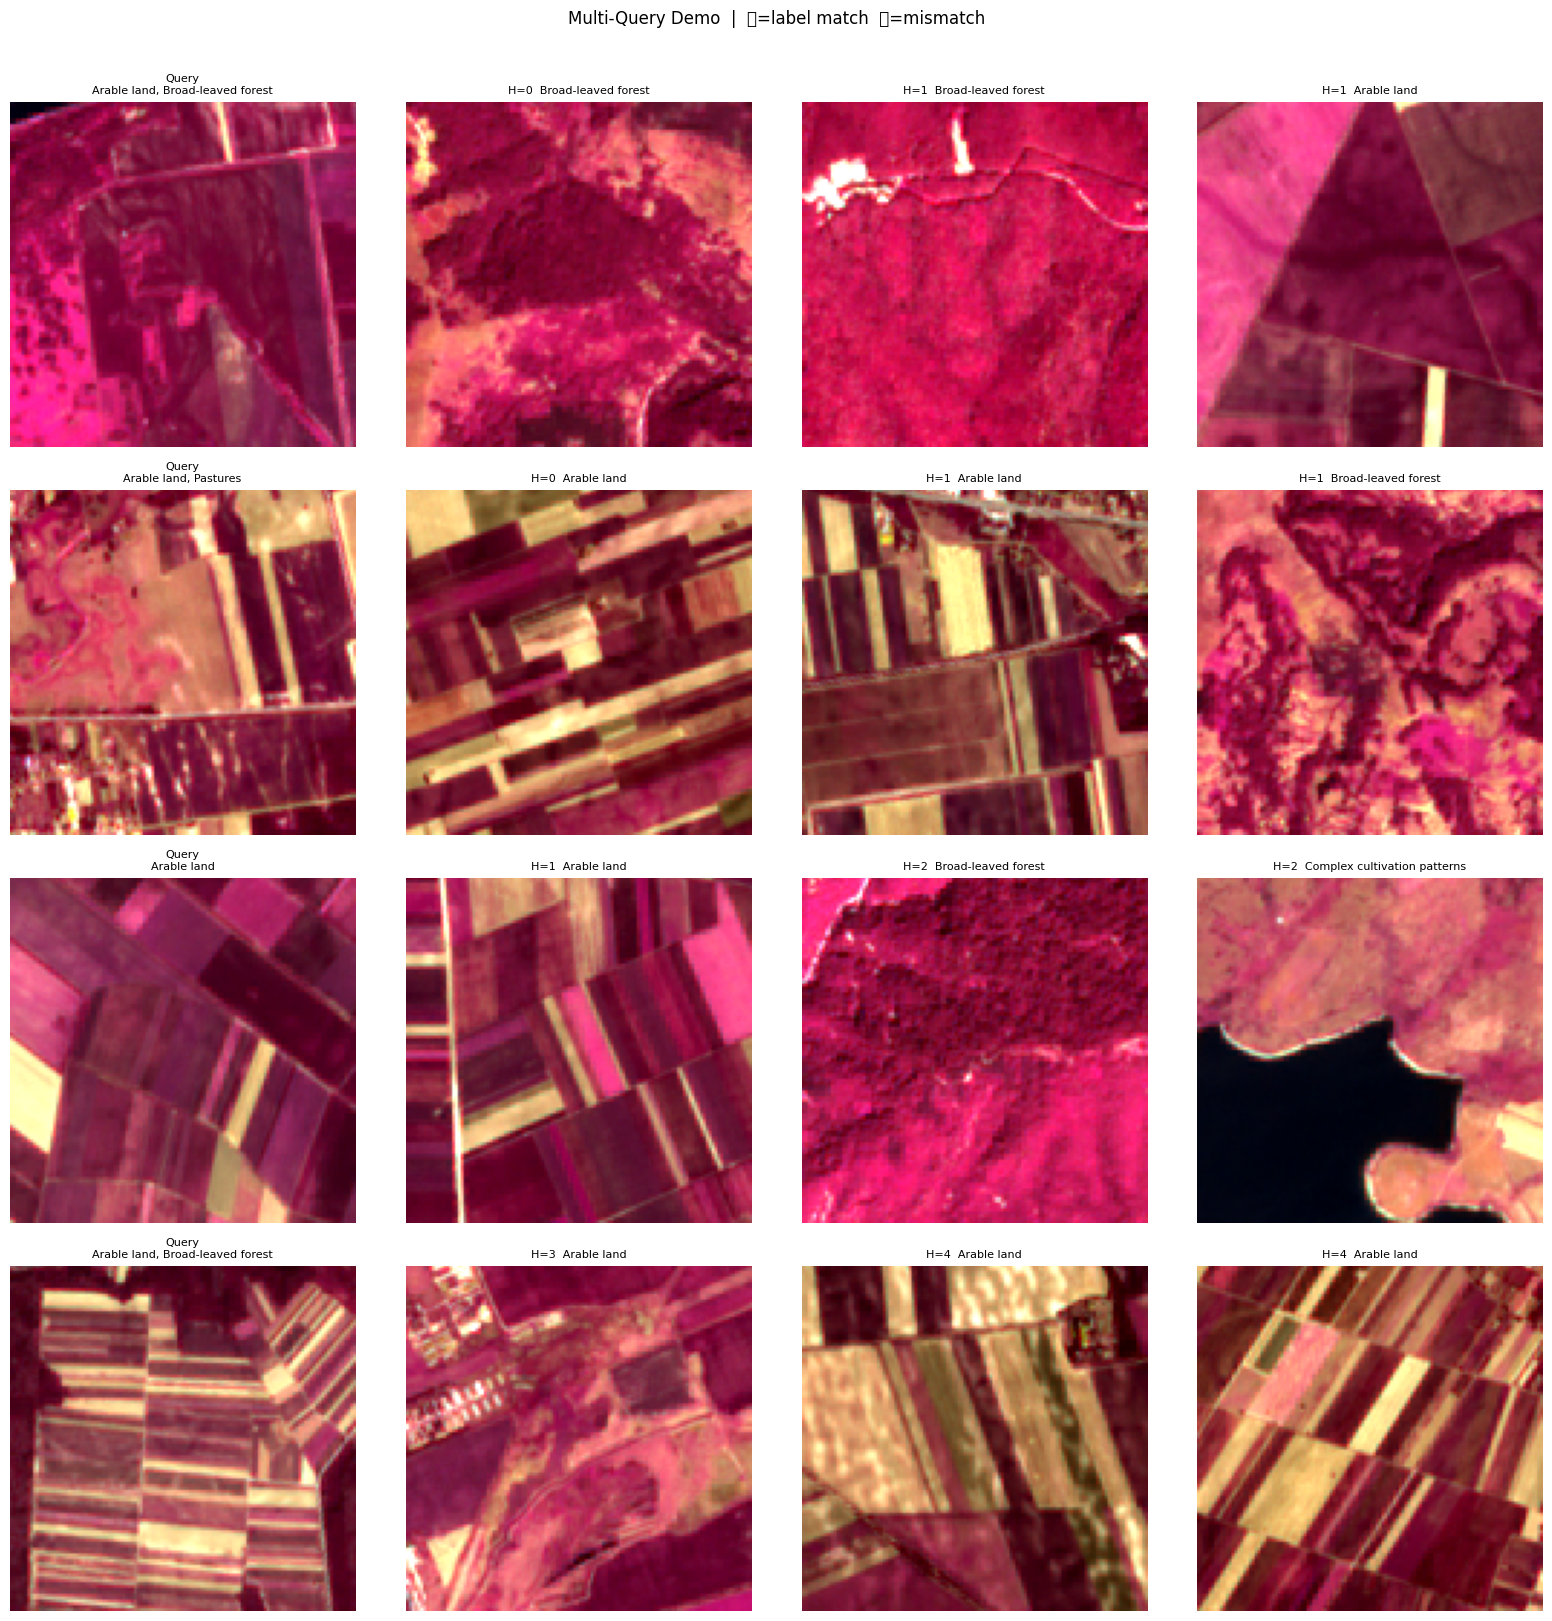

In [32]:
# ============================================================
# PHASE 16 — MULTI-QUERY DEMO GRID
# ============================================================
demo_indices = [5, 50, 200, 500]
K_DEMO = 3

fig, axes = plt.subplots(len(demo_indices), K_DEMO + 1,
                         figsize=(4 * (K_DEMO + 1), 4 * len(demo_indices)))

for row, qi in enumerate(demo_indices):
    fname  = image_files[qi]
    qimg_d, matches_ = retrieve_similar(os.path.join(train_path, fname), k=K_DEMO)
    ql_d   = get_labels(fname)

    axes[row][0].imshow(to_rgb(qimg_d))
    axes[row][0].set_title(f"Query\n{', '.join(ql_d[:2])}", fontsize=8)
    axes[row][0].axis("off")

    for col, (mfname, dist) in enumerate(matches_):
        with rasterio.open(os.path.join(train_path, mfname)) as src:
            mimg = np.transpose(src.read(), (1, 2, 0))
        ml  = get_labels(mfname)
        hit = bool(set(ql_d) & set(ml) - {"(no label)"})
        axes[row][col+1].imshow(to_rgb(mimg))
        for sp in axes[row][col+1].spines.values():
            sp.set_edgecolor("limegreen" if hit else "red"); sp.set_linewidth(3)
        axes[row][col+1].set_title(f"H={dist}  {', '.join(ml[:1])}", fontsize=8)
        axes[row][col+1].axis("off")

plt.suptitle("Multi-Query Demo  |  🟢=label match  🔴=mismatch", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("multi_query_v7.png", dpi=120, bbox_inches="tight")
plt.show()